In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
import time
import matplotlib.pyplot as plt

c:\Program Files\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL = "bert-base-uncased"
MAX_LEN = 128
BATCH = 16
EPOCHS = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
dataset = load_dataset("glue", "sst2")
tokenizer = BertTokenizer.from_pretrained(MODEL)

def tok(x):
    return tokenizer(x["sentence"], padding="max_length",
                     truncation=True, max_length=MAX_LEN)

dataset = dataset.map(tok, batched=True)
dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

train_loader = DataLoader(dataset["train"], batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(dataset["validation"], batch_size=BATCH)

In [4]:
def clear_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

In [ ]:
class Model(nn.Module):
    def __init__(self, freeze=False, drop=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(MODEL)

        if freeze:
            for p in self.bert.parameters():
                p.requires_grad = False

        self.fc = nn.Sequential(
            nn.Linear(768,256),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(256,1)
        )

    def forward(self, ids, mask):
        out = self.bert(input_ids=ids, attention_mask=mask)
        cls = out.last_hidden_state[:,0,:]
        return self.fc(cls)

In [ ]:
def run(freeze=False, lr=2e-5, drop=0.3):
    clear_cuda()
    model = Model(freeze, drop).to(DEVICE)
    opt = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    val_accs = []
    start = time.time()

    for e in range(EPOCHS):
        model.train()
        for b in train_loader:
            ids = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            y = b["label"].float().unsqueeze(1).to(DEVICE)

            opt.zero_grad()
            out = model(ids, mask)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()

        # eval
        model.eval()
        correct = 0
        with torch.no_grad():
            for b in val_loader:
                ids = b["input_ids"].to(DEVICE)
                mask = b["attention_mask"].to(DEVICE)
                y = b["label"].to(DEVICE)

                pred = (torch.sigmoid(model(ids,mask))>0.5).int().squeeze()
                correct += (pred==y).sum().item()

        acc = correct/len(val_loader.dataset)
        val_accs.append(acc)
        print(f"Epoch {e+1} Acc={acc:.4f}")

    print("Time:", time.time()-start)
    return val_accs


In [6]:
frozen = run(freeze=True)
full   = run(freeze=False)

Epoch 1 Acc=0.8417
Epoch 2 Acc=0.8498
Epoch 3 Acc=0.8521
Time: 822.9522395133972
Epoch 1 Acc=0.9232
Epoch 2 Acc=0.9083
Epoch 3 Acc=0.9163
Time: 3128.4395322799683


In [7]:
lr1 = run(lr=2e-5)
lr2 = run(lr=5e-5)

Epoch 1 Acc=0.9197
Epoch 2 Acc=0.9266
Epoch 3 Acc=0.9174
Time: 3115.696386575699
Epoch 1 Acc=0.8922
Epoch 2 Acc=0.9037
Epoch 3 Acc=0.8796
Time: 3038.88117647171


In [8]:
drop1 = run(drop=0.1)
drop2 = run(drop=0.3)

Epoch 1 Acc=0.9094
Epoch 2 Acc=0.9186
Epoch 3 Acc=0.9232
Time: 3010.1139142513275
Epoch 1 Acc=0.9220
Epoch 2 Acc=0.9174
Epoch 3 Acc=0.9140
Time: 2994.57181763649


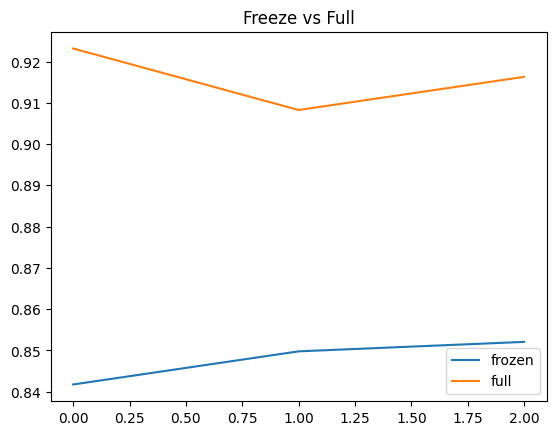

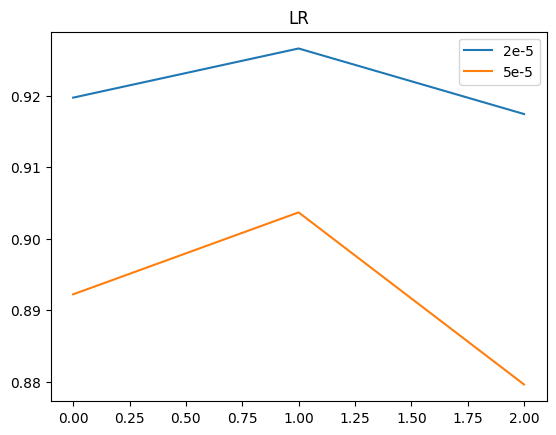

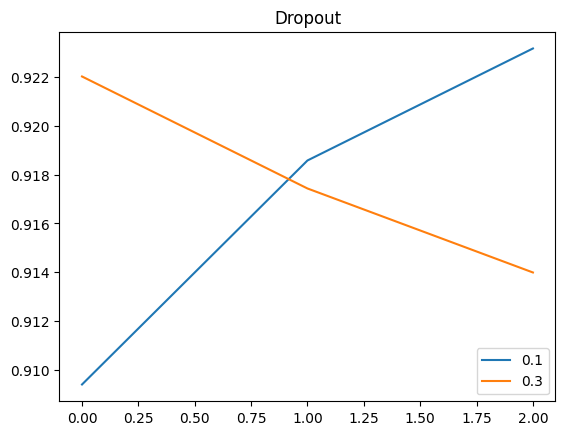

In [9]:
plt.plot(frozen,label="frozen")
plt.plot(full,label="full")
plt.legend(); plt.title("Freeze vs Full"); plt.show()

plt.plot(lr1,label="2e-5")
plt.plot(lr2,label="5e-5")
plt.legend(); plt.title("LR"); plt.show()

plt.plot(drop1,label="0.1") 
plt.plot(drop2,label="0.3")
plt.legend(); plt.title("Dropout"); plt.show()

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


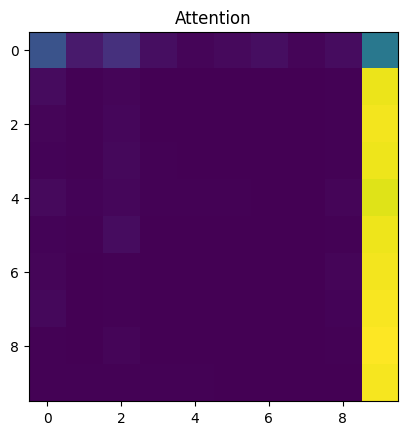

In [10]:
def show_attention(text):
    m = Model().to(DEVICE)
    t = tokenizer(text, return_tensors="pt").to(DEVICE)
    out = m.bert(**t, output_attentions=True)
    att = out.attentions[-1][0][0].detach().cpu()

    plt.imshow(att)
    plt.title("Attention")
    plt.show()

show_attention("this movie was extremely good but slightly slow")